# LOGICA FUZZY

Instalamos nuestra libreria

In [1]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 22.4 MB/s eta 0:00:00


Importamos nuestras libreria numpy, skfuzzy y control

In [3]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

Ahora vamos a establecer nuestra variables de entrada y salida.

In [27]:
# Nuevas variables difusas
velocidad = ctrl.Antecedent(np.arange(0, 1000, 1), 'velocidad')
angulo = ctrl.Antecedent(np.arange(-10, 10, 1), 'angulo')
posicion = ctrl.Consequent(np.arange(0, 10, 1), 'posicion')

# Funciones de membresía de velocidad
velocidad['bajo'] = fuzz.trapmf(velocidad.universe, [0, 0, 450, 500])
velocidad['ok'] = fuzz.trimf(velocidad.universe, [450, 550, 700])
velocidad['alto'] = fuzz.trapmf(velocidad.universe, [550, 850, 1000, 1000])

# Funciones de membresía de angulo
angulo['bajo'] = fuzz.trapmf(angulo.universe, [-10, -10, -5, 0])
angulo['leve'] = fuzz.trimf(angulo.universe, [-5, 0, 5])
angulo['alto'] = fuzz.trapmf(angulo.universe, [0, 5, 10, 10])

# Funciones de membresía de posicion
posicion['bajo'] = fuzz.trapmf(posicion.universe, [0, 0, 0, 4])
posicion['bm'] = fuzz.trimf(posicion.universe, [2, 4, 6])
posicion['media'] = fuzz.trimf(posicion.universe, [4, 6, 8])
posicion['am'] = fuzz.trimf(posicion.universe, [6, 8, 10])
posicion['alto'] = fuzz.trapmf(posicion.universe, [8, 10, 10, 10])

Mostramos los graficos

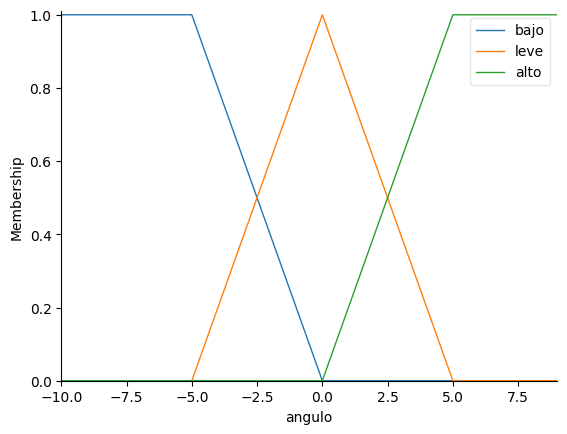

In [16]:
angulo.view()

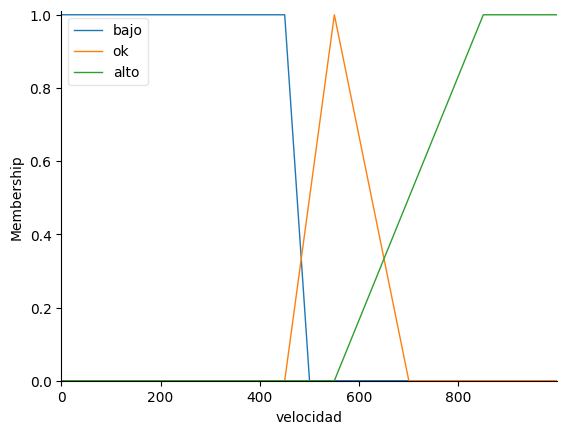

In [17]:
velocidad.view()

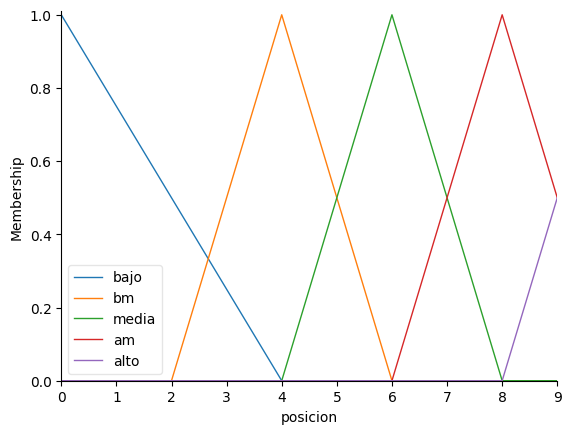

In [29]:
posicion.view()

In [30]:
# Reglas

# Si la velocidad es alta y el angulo es alto entonces la posicion es bm
rule1 = ctrl.Rule(velocidad['alto'] & angulo['alto'], posicion['bm'])

# Si la velocidad es alta y el angulo leve etnocnes la posicioon es bm
rule2 = ctrl.Rule(velocidad['alto'] & angulo['leve'], posicion['bm'])

# Si la velocidad es alta, y el angulo bajo entonces la posicion es baja
rule3 = ctrl.Rule(velocidad['alto'] & angulo['bajo'], posicion['bajo'])


# Si la velocidad es ok y el angulo alto entonces la posicion es alta media
rule4 = ctrl.Rule(velocidad['ok'] & angulo['alto'], posicion['am'])

# Si la velocidad es ok y el angulo es leve entonces la posicion es media
rule5 = ctrl.Rule(velocidad['ok'] & angulo['leve'], posicion['media'])

# Si la velocidad es ok y el angulo es bajo entonces la posicion es baja media
rule6 = ctrl.Rule(velocidad['ok'] & angulo['bajo'], posicion['bm'])


# Si la velocidad es baja y el angulo alto entonces la posicion sera alta
rule7 = ctrl.Rule(velocidad['bajo'] & angulo['alto'], posicion['alto'])

# Si la velocidad es baja y el angulo leve entonces la posicion sera alta media
rule8 = ctrl.Rule(velocidad['bajo'] & angulo['leve'], posicion['am'])

# Si la velocidad es baja y el angulo bajo entonces la posicion sera alta media
rule9 = ctrl.Rule(velocidad['bajo'] & angulo['bajo'], posicion['am'])

In [32]:
# Sistema de control
pos_control = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9])
pos_simulation = ctrl.ControlSystemSimulation(pos_control)

# Entradas
pos_simulation.input['velocidad'] = 515
pos_simulation.input['angulo'] = -2.5

# Computa la salida
pos_simulation.compute()

Posicion del timon: 5.0


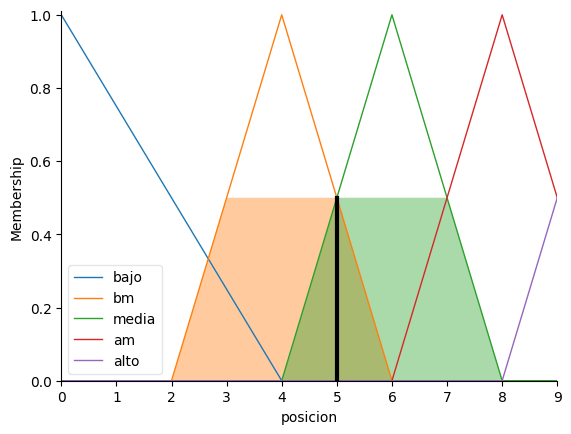

In [33]:
print(f"Posicion del timon: {pos_simulation.output['posicion']}")
posicion.view(sim=pos_simulation)